In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [5]:
# Superfície sintética no estilo "função de custo" J(w₁, w₂): não vem de um modelo nem de dados;
# serve só para visualizar um relevo 3D parecido com loss em função de dois pesos.

# Vetores 1D: 100 valores igualmente espaçados no intervalo [-5, 5] para cada eixo.
x1d = np.linspace(-5, 5, 100)
y1d = np.linspace(-5, 5, 100)

# meshgrid: transforma os dois vetores em grades 2D X e Y do mesmo tamanho.
# Em cada posição (i, j): X[i,j] é um valor do eixo w₁ e Y[i,j] é um valor do eixo w₂,
# percorrendo TODOS os pares (w₁, w₂) do quadrado. Assim dá para calcular Z de uma vez
# com operações vetoriais (X**2, np.sin(X), etc.) em vez de loop aninhado.
X, Y = np.meshgrid(x1d, y1d)

# "Chamada" da função de custo aqui é só esta expressão numérica: Z = J(X, Y).
# - (X**2 + Y**2) / 10 → parábola radial (bacia) com mínimo perto de (0, 0);
# - np.sin(X) * np.cos(Y) → ondulações (vários mínimos locais), típico de superfícies não convexas.
Z = (X**2 + Y**2) / 10 + np.sin(X) * np.cos(Y)


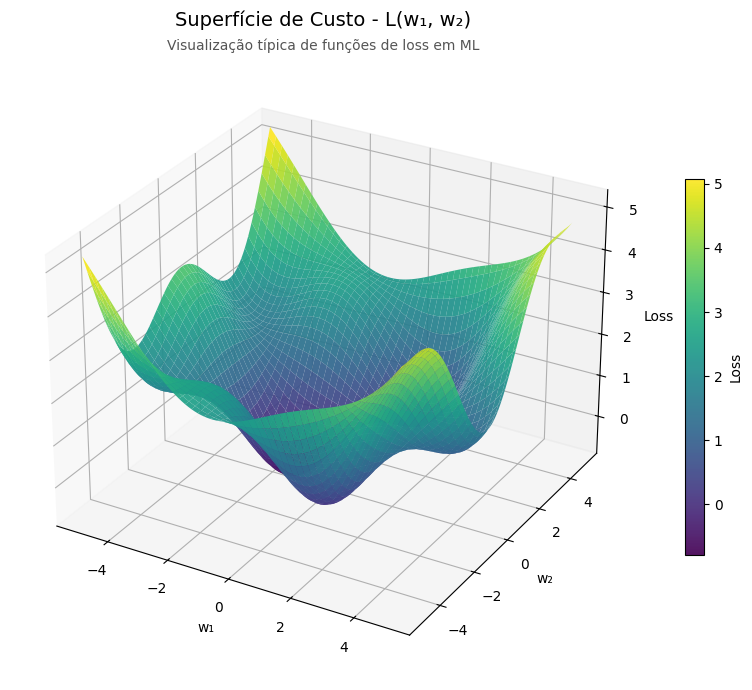

In [9]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.92, antialiased=True)

ax.set_title("Superfície de Custo - L(w₁, w₂)", fontsize=14, pad=20)
ax.text2D(0.5, 1, "Visualização típica de funções de loss em ML",
          transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='#555555')

ax.set_xlabel("w₁")
ax.set_ylabel("w₂")
ax.set_zlabel("Loss")

fig.colorbar(surf, ax=ax, shrink=0.6, label="Loss")
ax.view_init(elev=28, azim=-60)

plt.tight_layout()
plt.savefig("surface_loss.png", dpi=1000)
plt.show()